# Imports

In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import matplotlib.pyplot as plt
import awkward           as ak
import numpy             as np
import pandas            as pd

from nHits_trigger.src.read_data          import nHits, read_mpmt_offsets
from WCTE_BRB_Data_Analysis.wcte.brbtools import sort_run_files, get_part_files
from matplotlib.backends.backend_pdf      import PdfPages

from tqdm import tqdm

plt.style.use('default');
pltext.style()

# Read Data And Correct TOF

In [2]:
bkg_run = 1766

bkg_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{bkg_run}/WCTE_offline_R{bkg_run}S*P*.root")
bkg_part_files = get_part_files(bkg_run_files)

# Run Variables
bkg_run_corrected_times           = []
bkg_run_hit_charges               = []
bkg_run_hit_card_ids              = []
bkg_run_hit_channel_ids           = []
bkg_run_hit_slot_ids              = []
bkg_run_hit_position_ids          = []
bkg_run_hit_pmt_has_time_constant = []

ev_offset = 0
for part in bkg_part_files[:1]:
    print(f"Processing part WCTE_offline_R{bkg_run}S0P{part}")
    bkg_tree = uproot.open(bkg_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    bkg_file_hit_card_ids              = ak.values_astype(bkg_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    bkg_file_hit_channel_ids           = ak.values_astype(bkg_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    bkg_file_hit_times                 = ak.values_astype(bkg_tree["hit_pmt_times"]            .array(), np.float64)
    bkg_file_hit_times_calib           = ak.values_astype(bkg_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    bkg_file_hit_charges               = ak.values_astype(bkg_tree["hit_pmt_charges"]          .array(), np.float64)
    bkg_file_hit_slot_ids              = ak.values_astype(bkg_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    bkg_file_hit_position_ids          = ak.values_astype(bkg_tree["hit_pmt_position_ids"]     .array(), np.int16)
    bkg_file_hit_pmt_has_time_constant = ak.values_astype(bkg_tree["hit_pmt_has_time_constant"].array(), np.bool)

    mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1767.json")

    max_slot = 106
    max_pos  = 19

    # Build lookup
    lookup = np.zeros((max_slot, max_pos))
    for (card, chan), shift in mpmt_map.items():
        lookup[card, chan] = shift

    # Hit Times Correction
    bkg_flat_slot_ids     = ak.ravel(bkg_file_hit_slot_ids)
    bkg_flat_pos_ids      = ak.ravel(bkg_file_hit_position_ids)
    bkg_flat_corrections  = lookup[bkg_flat_slot_ids, bkg_flat_pos_ids]
    bkg_corrections       = ak.unflatten(bkg_flat_corrections, ak.num(bkg_file_hit_card_ids))

    bkg_term1           = bkg_file_hit_times_calib
    bkg_corrected_times = bkg_term1 #- bkg_corrections 

    # Filter Out Main Things
    mask = (bkg_file_hit_charges < 1e4) & (bkg_file_hit_card_ids < 120) & (bkg_file_hit_pmt_has_time_constant != 0)
    bkg_corrected_times                = bkg_corrected_times                [mask]
    bkg_file_hit_charges               = bkg_file_hit_charges               [mask]
    bkg_file_hit_card_ids              = bkg_file_hit_card_ids              [mask]
    bkg_file_hit_channel_ids           = bkg_file_hit_channel_ids           [mask]
    bkg_file_hit_slot_ids              = bkg_file_hit_slot_ids              [mask]
    bkg_file_hit_position_ids          = bkg_file_hit_position_ids          [mask]
    bkg_file_hit_pmt_has_time_constant = bkg_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(bkg_corrected_times)
    
    bkg_run_corrected_times          .append(bkg_corrected_times               [order])
    bkg_run_hit_charges              .append(bkg_file_hit_charges              [order])
    bkg_run_hit_card_ids             .append(bkg_file_hit_card_ids             [order])    
    bkg_run_hit_channel_ids          .append(bkg_file_hit_channel_ids          [order]) 
    bkg_run_hit_slot_ids             .append(bkg_file_hit_slot_ids             [order])    
    bkg_run_hit_position_ids         .append(bkg_file_hit_position_ids         [order])
    bkg_run_hit_pmt_has_time_constant.append(bkg_file_hit_pmt_has_time_constant[order])

bkg_run_corrected_times           = ak.concatenate(bkg_run_corrected_times          )
bkg_run_hit_charges               = ak.concatenate(bkg_run_hit_charges              )
bkg_run_hit_card_ids              = ak.concatenate(bkg_run_hit_card_ids             )
bkg_run_hit_channel_ids           = ak.concatenate(bkg_run_hit_channel_ids          )
bkg_run_hit_slot_ids              = ak.concatenate(bkg_run_hit_slot_ids             )
bkg_run_hit_position_ids          = ak.concatenate(bkg_run_hit_position_ids         )
bkg_run_hit_pmt_has_time_constant = ak.concatenate(bkg_run_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1766S0P0


In [3]:
nicf_run = 1767

nicf_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{nicf_run}/WCTE_offline_R{nicf_run}S*P*.root")
nicf_part_files = get_part_files(nicf_run_files)

# Run Variables
nicf_run_tof_corrected_times           = []
nicf_run_tof_hit_charges               = []
nicf_run_tof_hit_card_ids              = []
nicf_run_tof_hit_channel_ids           = []
nicf_run_tof_hit_slot_ids              = []
nicf_run_tof_hit_position_ids          = []
nicf_run_tof_hit_pmt_has_time_constant = []

ev_offset = 0
for part in nicf_part_files[:1]:
    print(f"Processing part WCTE_offline_R{nicf_run}S0P{part}")
    nicf_tree = uproot.open(nicf_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    nicf_file_hit_card_ids              = ak.values_astype(nicf_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    nicf_file_hit_channel_ids           = ak.values_astype(nicf_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    nicf_file_hit_times                 = ak.values_astype(nicf_tree["hit_pmt_times"]            .array(), np.float64)
    nicf_file_hit_times_calib           = ak.values_astype(nicf_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    nicf_file_hit_charges               = ak.values_astype(nicf_tree["hit_pmt_charges"]          .array(), np.float64)
    nicf_file_hit_slot_ids              = ak.values_astype(nicf_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    nicf_file_hit_position_ids          = ak.values_astype(nicf_tree["hit_pmt_position_ids"]     .array(), np.int16)
    nicf_file_hit_pmt_has_time_constant = ak.values_astype(nicf_tree["hit_pmt_has_time_constant"].array(), np.bool)

    mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1767.json")

    max_slot = 106
    max_pos  = 19

    # Build lookup
    lookup = np.zeros((max_slot, max_pos))
    for (card, chan), shift in mpmt_map.items():
        lookup[card, chan] = shift

    # Hit Times Correction
    nicf_flat_slot_ids     = ak.ravel(nicf_file_hit_slot_ids)
    nicf_flat_pos_ids      = ak.ravel(nicf_file_hit_position_ids)
    nicf_flat_corrections  = lookup[nicf_flat_slot_ids, nicf_flat_pos_ids]
    nicf_corrections       = ak.unflatten(nicf_flat_corrections, ak.num(nicf_file_hit_card_ids))

    nicf_term1           = nicf_file_hit_times_calib
    nicf_corrected_times = nicf_term1 #- nicf_corrections 

    # Filter Out Main Things
    mask = (nicf_file_hit_charges < 1e4) & (nicf_file_hit_card_ids < 120) & (nicf_file_hit_pmt_has_time_constant != 0)
    nicf_corrected_times                = nicf_corrected_times                [mask]
    nicf_file_hit_charges               = nicf_file_hit_charges               [mask]
    nicf_file_hit_card_ids              = nicf_file_hit_card_ids              [mask]
    nicf_file_hit_channel_ids           = nicf_file_hit_channel_ids           [mask]
    nicf_file_hit_slot_ids              = nicf_file_hit_slot_ids              [mask]
    nicf_file_hit_position_ids          = nicf_file_hit_position_ids          [mask]
    nicf_file_hit_pmt_has_time_constant = nicf_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(nicf_corrected_times)
    
    nicf_run_tof_corrected_times          .append(nicf_corrected_times               [order])
    nicf_run_tof_hit_charges              .append(nicf_file_hit_charges              [order])
    nicf_run_tof_hit_card_ids             .append(nicf_file_hit_card_ids             [order])    
    nicf_run_tof_hit_channel_ids          .append(nicf_file_hit_channel_ids          [order]) 
    nicf_run_tof_hit_slot_ids             .append(nicf_file_hit_slot_ids             [order])    
    nicf_run_tof_hit_position_ids         .append(nicf_file_hit_position_ids         [order])
    nicf_run_tof_hit_pmt_has_time_constant.append(nicf_file_hit_pmt_has_time_constant[order])

nicf_run_tof_corrected_times           = ak.concatenate(nicf_run_tof_corrected_times          )
nicf_run_tof_hit_charges               = ak.concatenate(nicf_run_tof_hit_charges              )
nicf_run_tof_hit_card_ids              = ak.concatenate(nicf_run_tof_hit_card_ids             )
nicf_run_tof_hit_channel_ids           = ak.concatenate(nicf_run_tof_hit_channel_ids          )
nicf_run_tof_hit_slot_ids              = ak.concatenate(nicf_run_tof_hit_slot_ids             )
nicf_run_tof_hit_position_ids          = ak.concatenate(nicf_run_tof_hit_position_ids         )
nicf_run_tof_hit_pmt_has_time_constant = ak.concatenate(nicf_run_tof_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1767S0P0


# Spills

In [4]:
len(bkg_run_corrected_times) == len(nicf_run_tof_corrected_times)

True

In [5]:
nicf_triggered_spill_hits_index_tof, nicf_triggered_spill_hit_times_tof = nHits(mode="multiple_events", hit_times=nicf_run_tof_corrected_times, w=5000, thresh_min=300, thresh_max=100000, pre_window=0, post_window=4000, jump=9000)
bkg_triggered_spill_hits_index, bkg_triggered_spill_hit_times           = nHits(mode="multiple_events", hit_times=bkg_run_corrected_times,      w=5000, thresh_min=300, thresh_max=100000, pre_window=0, post_window=4000, jump=9000)

  0%|          | 0/11113 [00:00<?, ?it/s]

100%|██████████| 11113/11113 [00:03<00:00, 3083.82it/s]


### Remove Spills from data

In [6]:
def remove_spill(trigger_indices, run_times):
    corrected_run_times = []

    for i in tqdm(range(len(run_times))):
        if i in trigger_indices:
            #Event with spill → remove selected indices
            if len(trigger_indices[i]) > 0:
                data = run_times[i]
                trigger_indices_event = np.concatenate(trigger_indices[i])
                all_indices           = np.arange(len(data))
                valid_indices         = np.setdiff1d(all_indices, trigger_indices_event)
                corrected_run_times.append(data[valid_indices])
            
            else:
                continue
        else:
            # Event without spill → leave as it is
            corrected_run_times.append(run_times[i])

    return ak.Array(corrected_run_times)

In [7]:
# Hit Time
nicf_noSpill_times_tof = remove_spill(nicf_triggered_spill_hits_index_tof, nicf_run_tof_corrected_times)
bkg_noSpill_times      = remove_spill(bkg_triggered_spill_hits_index, bkg_run_corrected_times)

100%|██████████| 11113/11113 [00:02<00:00, 4988.98it/s]


### Spill Analysis

In [8]:
#¿Cuántos spill estoy quitando por readout-window?

nOfSpillsPerEvent_sig = []
for k,v in nicf_triggered_spill_hit_times_tof.items():
    nOfSpillsPerEvent_sig.append(len(v))

nOfSpillsPerEvent_bkg = []
for k,v in bkg_triggered_spill_hit_times.items():
    nOfSpillsPerEvent_bkg.append(len(v))

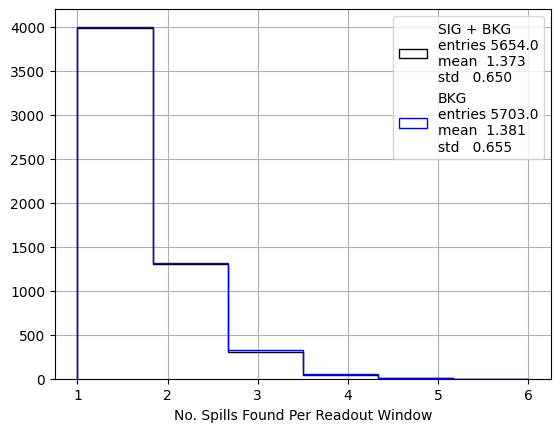

In [9]:
pltext.hist(nOfSpillsPerEvent_sig, np.max(nOfSpillsPerEvent_sig), xylabels="No. Spills Found Per Readout Window", label="SIG + BKG");
pltext.hist(nOfSpillsPerEvent_bkg, np.max(nOfSpillsPerEvent_bkg), xylabels="No. Spills Found Per Readout Window", label="BKG");

In [10]:
# Distribución del número de hits en el spill (en 5000 ns y en los 4000 ns posteriores)

spill_size_sig = []

for k,v in tqdm(nicf_triggered_spill_hit_times_tof.items(), total=len(nicf_triggered_spill_hit_times_tof.items()), leave=False):
    for i in nicf_triggered_spill_hit_times_tof.get(k):
        spill_size_sig.append(len(i))

spill_size_bkg = []

for k,v in tqdm(bkg_triggered_spill_hit_times.items(), total=len(bkg_triggered_spill_hit_times.items()), leave=False):
    for i in bkg_triggered_spill_hit_times.get(k):
        spill_size_bkg.append(len(i))

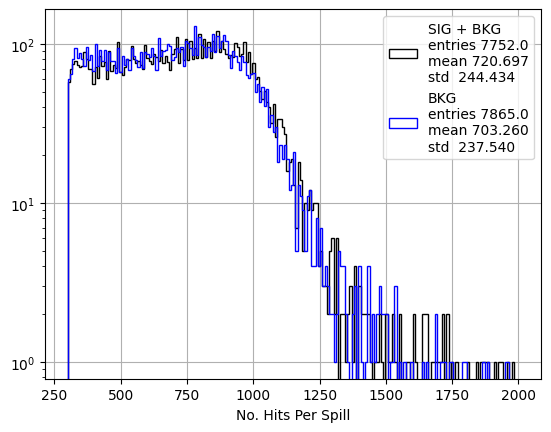

In [11]:
pltext.hist(spill_size_sig, 200, range=(300, 2000), ylog=True, xylabels="No. Hits Per Spill", label="SIG + BKG");
pltext.hist(spill_size_bkg, 200, range=(300, 2000), ylog=True, xylabels="No. Hits Per Spill", label="BKG");

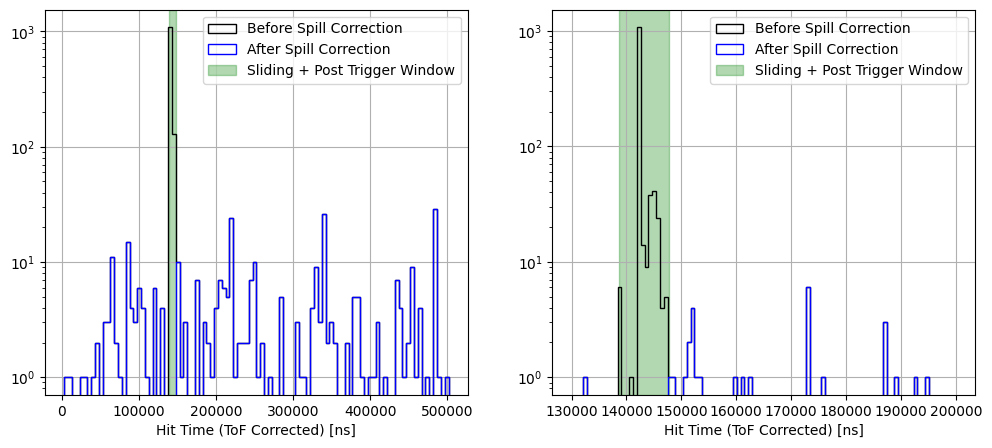

In [12]:
ev = 0

subplot = pltext.canvas(2)

subplot(1)
pltext.hist(nicf_run_tof_corrected_times[ev], 100, ylog=True, xylabels="Hit Time (ToF Corrected) [ns]", stats=False, label="Before Spill Correction");
pltext.hist(nicf_noSpill_times_tof[ev],       100, ylog=True, xylabels="Hit Time (ToF Corrected) [ns]", stats=False, label="After Spill Correction");
plt.axvspan(nicf_triggered_spill_hit_times_tof[ev][0][0], nicf_triggered_spill_hit_times_tof[ev][0][0]+9e3, color="green", alpha=0.3, label="Sliding + Post Trigger Window");
plt.legend();

subplot(2)
pltext.hist(nicf_run_tof_corrected_times[ev], 100, range=(1.3e5, 2e5), ylog=True, xylabels="Hit Time (ToF Corrected) [ns]", stats=False, label="Before Spill Correction");
pltext.hist(nicf_noSpill_times_tof[ev],       100, range=(1.3e5, 2e5), ylog=True, xylabels="Hit Time (ToF Corrected) [ns]", stats=False, label="After Spill Correction");
plt.axvspan(nicf_triggered_spill_hit_times_tof[ev][0][0], nicf_triggered_spill_hit_times_tof[ev][0][0]+9e3, color="green", alpha=0.3, label="Sliding + Post Trigger Window");
plt.legend();

# Candidates Analysis

In [13]:
def nHits(mode,
          hit_times,
          w,
          thresh_min,
          thresh_max,
          pre_window,
          post_window,
          jump,
          event=0,
          progress_bar=True):

    def process_event(ht,
                      w,
                      thresh_min,
                      thresh_max,
                      pre_window,
                      post_window,
                      jump):

        if len(ht) == 0:
            return [], [], [], []

        # Orden temporal
        ht = np.sort(ht)

        # ------------------------
        # Sliding window trigger
        # ------------------------

        ends = ht + w
        right = np.searchsorted(ht, ends, side="left")
        left = np.arange(len(ht))
        counts = right - left

        trigger_indices = np.where(counts >= thresh_min)[0]

        triggered_hits_index = []
        triggered_hits_time = []

        trigger_seeds = []      # t_seed (paper SLE crossing)
        roi_start_times = []   # primer hit físico del cluster

        last_cluster_end = -np.inf

        # ------------------------
        # Loop triggers
        # ------------------------

        for idx in trigger_indices:

            t_seed = ht[idx]

            # Deadtime basado en CLUSTER REAL
            if t_seed < last_cluster_end + jump:
                continue

            # ------------------------
            # ROI física
            # ------------------------

            t_min = t_seed - pre_window
            t_max = t_seed + w + post_window

            roi_mask = (ht >= t_min) & (ht <= t_max)
            indices_roi = np.where(roi_mask)[0]

            if len(indices_roi) < thresh_min:
                continue
            
            if thresh_max is not None and len(indices_roi) > thresh_max:
                continue

            hit_times_roi = ht[indices_roi]

            # ------------------------
            # Guardado
            # ------------------------

            triggered_hits_index.append(indices_roi)
            triggered_hits_time.append(hit_times_roi)

            trigger_seeds.append(t_seed)
            roi_start_times.append(hit_times_roi[0])

            # Deadtime real: fin del cluster físico
            last_cluster_end = hit_times_roi[-1]

        return triggered_hits_index, triggered_hits_time, trigger_seeds, roi_start_times

    # ==================================================
    # SINGLE EVENT
    # ==================================================

    if mode == "single_event":

        ht = ak.to_numpy(hit_times[event])

        idxs, times, seeds, roi_starts = process_event(
            ht,
            w,
            thresh_min,
            thresh_max,
            pre_window,
            post_window,
            jump
        )

        return ({event: idxs},
                {event: times},
                {event: seeds},
                {event: roi_starts})

    # ==================================================
    # MULTIPLE EVENTS
    # ==================================================

    elif mode == "multiple_events":

        nevents = len(hit_times)

        triggered_hits_index = {}
        triggered_hits_time = {}
        trigger_seeds_dict = {}
        roi_start_times_dict = {}

        for event in tqdm(range(nevents),
                          total=nevents,
                          leave=progress_bar):

            ht = ak.to_numpy(hit_times[event])

            if len(ht) == 0:
                triggered_hits_index[event] = []
                triggered_hits_time[event] = []
                trigger_seeds_dict[event] = []
                roi_start_times_dict[event] = []
                continue

            idxs, times, seeds, roi_starts = process_event(
                ht,
                w,
                thresh_min,
                thresh_max,
                pre_window,
                post_window,
                jump
            )

            triggered_hits_index[event] = idxs
            triggered_hits_time[event] = times
            trigger_seeds_dict[event] = seeds
            roi_start_times_dict[event] = roi_starts

        return (triggered_hits_index,
                triggered_hits_time,
                trigger_seeds_dict,
                roi_start_times_dict)

    else:
        print("enter a valid mode name")
        return {}, {}, {}, {}


In [14]:
thresh_inf          = 5   # hits
thresh_sup          = 60   # hits
sliding_window      = 20   # ns
pre_trigger_window  = 200
post_trigger_window = 200
dead_time           = pre_trigger_window + post_trigger_window    # ns

# nHits
nicf_triggered_signal_hits_index_tof, nicf_triggered_signal_hit_times_tof, nicf_d_seed_tof, nicf_d_roi_tof = nHits(mode="multiple_events", hit_times=nicf_noSpill_times_tof, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time)
bkg_triggered_signal_hits_index_tof, bkg_triggered_signal_hit_times_tof, bkg_d_seed_tof, bkg_d_roi_tof     = nHits(mode="multiple_events", hit_times=bkg_noSpill_times,      w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time)

# tRMS
nicf_rms_50ns_tof  = []
nicf_50ns_size_tof = []
for k,v in tqdm(nicf_triggered_signal_hit_times_tof.items(), total=len(nicf_triggered_signal_hit_times_tof.items()), leave=False):
        for i in nicf_triggered_signal_hit_times_tof.get(k):
            nicf_rms_50ns_tof.append(np.std(i, ddof=0))
            nicf_50ns_size_tof.append(len(i))

bkg_rms_50ns  = []
bkg_50ns_size = []
for k,v in tqdm(bkg_triggered_signal_hit_times_tof.items(), total=len(bkg_triggered_signal_hit_times_tof.items()), leave=False):
        for i in bkg_triggered_signal_hit_times_tof.get(k):
            bkg_rms_50ns.append(np.std(i, ddof=0))
            bkg_50ns_size.append(len(i))

100%|██████████| 11113/11113 [00:04<00:00, 2740.27it/s]


In [15]:
# Eliminamos ese candidato si en la ventana extendida [200, 20 + 200] hay alguna otra acumulación de hits > 10 en 20 ns 
# (que podemos llamar flash). Esto es en la ventana extendida solo está ese candidado con >10 hits 

doubleCandidates_sig = {}

for k,v in tqdm(nicf_triggered_signal_hit_times_tof.items(), total=len(nicf_triggered_signal_hit_times_tof.items())):
    event = k
    sett  = nicf_triggered_signal_hit_times_tof[event] 
    seed  = nicf_d_seed_tof[event]
    roi   = nicf_d_roi_tof[event]
    for c in range(len(v)):
        
        candidate_to_investigate = [sett[c] - seed[c]]
        thresh_inf               = 5     # hits
        thresh_sup               = np.inf # hits
        sliding_window           = 20     # ns
        pre_trigger_window       = 0      # ns  
        post_trigger_window      = 0      # ns
        dead_time                = sliding_window + post_trigger_window

        test_triggered_signal_hits_index_tof, test_triggered_signal_hit_times_tof, test_d_seed_tof, test_d_roi_tof = nHits(mode="single_event", hit_times=candidate_to_investigate, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time, event=0)

        if len(test_triggered_signal_hit_times_tof[0]) > 1:
            # print(k, c, ":", len(test_triggered_signal_hit_times_tof[0]))
            doubleCandidates_sig[k] = c

doubleCandidates_bkg = {}

for k,v in tqdm(bkg_triggered_signal_hit_times_tof.items(), total=len(bkg_triggered_signal_hit_times_tof.items())):
    event = k
    sett  = bkg_triggered_signal_hit_times_tof[event] 
    seed  = bkg_d_seed_tof[event]
    roi   = bkg_d_roi_tof[event]
    for c in range(len(v)):
        
        candidate_to_investigate = [sett[c] - seed[c]]
        thresh_inf               = 5     # hits
        thresh_sup               = np.inf # hits
        sliding_window           = 20     # ns
        pre_trigger_window       = 0      # ns  
        post_trigger_window      = 0      # ns
        dead_time                = sliding_window + post_trigger_window

        test_triggered_signal_hits_index_tof, test_triggered_signal_hit_times_tof, test_d_seed_tof, test_d_roi_tof = nHits(mode="single_event", hit_times=candidate_to_investigate, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time, event=0)

        if len(test_triggered_signal_hit_times_tof[0]) > 1:
            # print(k, c, ":", len(test_triggered_signal_hit_times_tof[0]))
            doubleCandidates_bkg[k] = c

100%|██████████| 11113/11113 [00:02<00:00, 3750.94it/s]


In [16]:
print(f"Estamos eliminando {len(doubleCandidates_sig)} candidatos por tener double triggers. Representa un {len(doubleCandidates_sig)/len(nicf_50ns_size_tof)*100:.2f}% del total de candidatos triggados.")
print(f"Estamos eliminando {len(doubleCandidates_bkg)} candidatos por tener double triggers. Representa un {len(doubleCandidates_bkg)/len(bkg_50ns_size)*100:.2f}% del total de candidatos triggados.")

Estamos eliminando 706 candidatos por tener double triggers. Representa un 0.52% del total de candidatos triggados.
Estamos eliminando 130 candidatos por tener double triggers. Representa un 0.38% del total de candidatos triggados.


In [17]:
from copy import deepcopy
from collections import defaultdict

nicf_triggered_signal_hit_times_tof_clean  = deepcopy(nicf_triggered_signal_hit_times_tof)
nicf_d_seed_tof_clean                      = deepcopy(nicf_d_seed_tof)
nicf_triggered_signal_hits_index_tof_clean = deepcopy(nicf_triggered_signal_hits_index_tof)

to_delete = defaultdict(list)
for k, idx in doubleCandidates_sig.items():
    to_delete[k].append(idx)

for k, indices in to_delete.items():
    for idx in sorted(indices, reverse=True):
        if k in nicf_triggered_signal_hit_times_tof_clean and idx < len(nicf_triggered_signal_hit_times_tof_clean[k]):
            del nicf_triggered_signal_hit_times_tof_clean[k][idx]
            del nicf_d_seed_tof_clean[k][idx]
            del nicf_triggered_signal_hits_index_tof_clean[k][idx]

bkg_triggered_signal_hit_times_tof_clean  = deepcopy(bkg_triggered_signal_hit_times_tof)
bkg_d_seed_tof_clean                      = deepcopy(bkg_d_seed_tof)
bkg_triggered_signal_hits_index_tof_clean = deepcopy(bkg_triggered_signal_hits_index_tof)

to_delete = defaultdict(list)
for k, idx in doubleCandidates_bkg.items():
    to_delete[k].append(idx)

for k, indices in to_delete.items():
    for idx in sorted(indices, reverse=True):
        if k in bkg_triggered_signal_hit_times_tof_clean and idx < len(bkg_triggered_signal_hit_times_tof_clean[k]):
            del bkg_triggered_signal_hit_times_tof_clean[k][idx]
            del bkg_d_seed_tof_clean[k][idx]
            del bkg_triggered_signal_hits_index_tof_clean[k][idx]

# 1st Purity Calculation

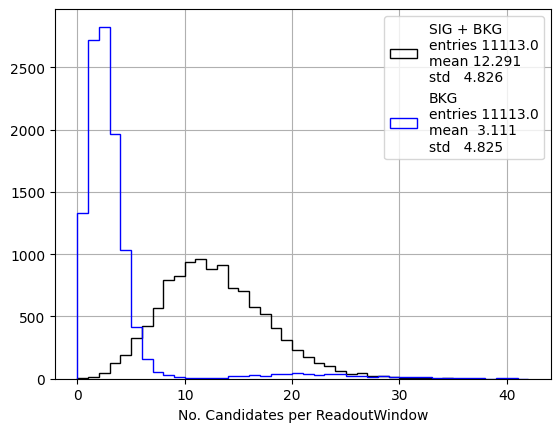

In [18]:
# 2. Cuántos candidatos hay en una readout window?
candidates_per_redaoutWindow_sig = []
for k,v in nicf_triggered_signal_hit_times_tof.items():
    candidates_per_redaoutWindow_sig.append(len(v))

candidates_per_redaoutWindow_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof.items():
    candidates_per_redaoutWindow_bkg.append(len(v))

pltext.hist(candidates_per_redaoutWindow_sig, np.max(candidates_per_redaoutWindow_sig), xylabels="No. Candidates per ReadoutWindow", label="SIG + BKG");
pltext.hist(candidates_per_redaoutWindow_bkg, np.max(candidates_per_redaoutWindow_bkg), xylabels="No. Candidates per ReadoutWindow", label="BKG");

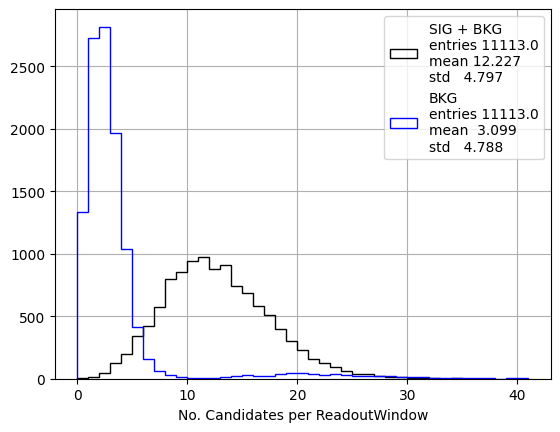

In [19]:
# 2. Cuántos candidatos hay en una readout window?
candidates_per_redaoutWindow_sig_clean = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    candidates_per_redaoutWindow_sig_clean.append(len(v))

candidates_per_redaoutWindow_bkg_clean = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    candidates_per_redaoutWindow_bkg_clean.append(len(v))

pltext.hist(candidates_per_redaoutWindow_sig_clean, np.max(candidates_per_redaoutWindow_sig_clean), xylabels="No. Candidates per ReadoutWindow", label="SIG + BKG");
pltext.hist(candidates_per_redaoutWindow_bkg_clean, np.max(candidates_per_redaoutWindow_bkg_clean), xylabels="No. Candidates per ReadoutWindow", label="BKG");

# $t_c$, $t_{RMS}$ and nHits In The Small Sliding Window

### Plots, Non PDFs

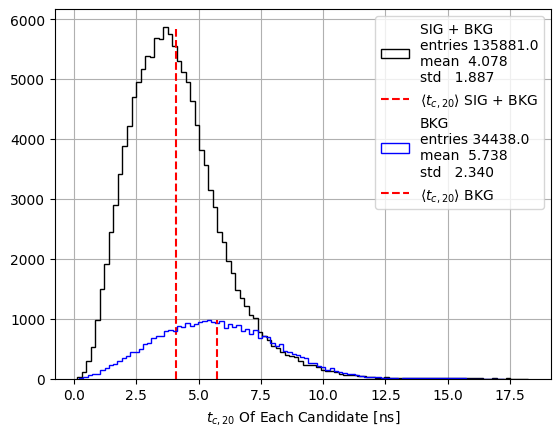

In [20]:
# 1. Calcular el tc de ese candidato como el promedio del tiempo de sus hits (los que están en la venta).

tc_20_sig = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
    seed  = nicf_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        mean_val = np.mean(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if mean_val is not None:
            tc_20_sig.append(mean_val)

tc_20_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
    seed  = bkg_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett < shifted_seed+20)
        mean_val = np.mean(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if mean_val is not None:
            tc_20_bkg.append(mean_val)

h = pltext.hist(tc_20_sig, 100, ylog=False, xylabels="$t_{c, 20}$ Of Each Candidate [ns]", label="SIG + BKG");
plt.vlines(np.mean(tc_20_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{c, 20} \rangle$ SIG + BKG");
h = pltext.hist(tc_20_bkg, 100, ylog=False, xylabels="$t_{c, 20}$ Of Each Candidate [ns]", label="BKG");
plt.vlines(np.mean(tc_20_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{c, 20} \rangle$ BKG");
plt.legend();

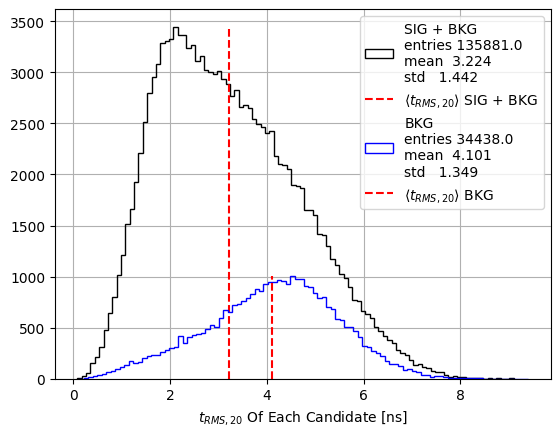

In [21]:
trms_20_sig = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
    seed  = nicf_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        std_val = np.std(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if std_val is not None:
            trms_20_sig.append(std_val)

trms_20_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
    seed  = bkg_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett < shifted_seed+20)
        std_val = np.std(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if std_val is not None:
            trms_20_bkg.append(std_val)

h = pltext.hist(trms_20_sig, 100, ylog=False, xylabels="$t_{RMS, 20}$ Of Each Candidate [ns]", label="SIG + BKG");
plt.vlines(np.mean(trms_20_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{RMS, 20} \rangle$ SIG + BKG");
h = pltext.hist(trms_20_bkg, 100, ylog=False, xylabels="$t_{RMS, 20}$ Of Each Candidate [ns]", label="BKG");
plt.vlines(np.mean(trms_20_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{RMS, 20} \rangle$ BKG");
plt.legend();

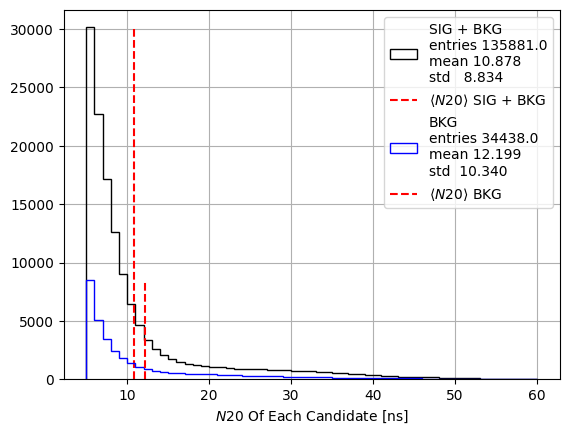

In [22]:
nhits_sig = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
    seed  = nicf_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        nhits_val = len(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if nhits_val is not None:
            nhits_sig.append(nhits_val)

nhits_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
    seed  = bkg_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        nhits_val = len(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if nhits_val is not None:
            nhits_bkg.append(nhits_val)

h = pltext.hist(nhits_sig, 55, ylog=False, xylabels="$N20$ Of Each Candidate [ns]", label="SIG + BKG");
plt.vlines(np.mean(nhits_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle N20 \rangle$ SIG + BKG");
h = pltext.hist(nhits_bkg, 55, ylog=False, xylabels="$N20$ Of Each Candidate [ns]", label="BKG");
plt.vlines(np.mean(nhits_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle N20 \rangle$ BKG");
plt.legend();

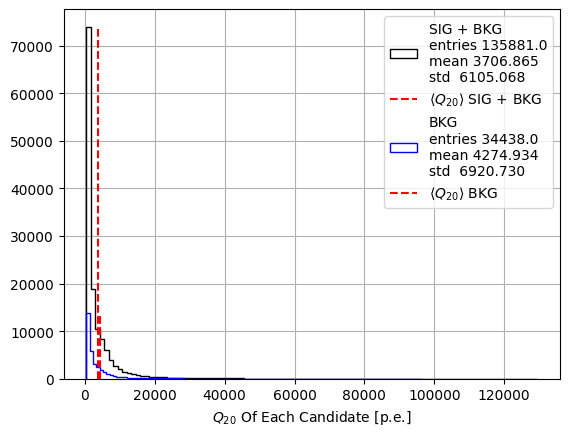

In [23]:
# ── NEW: Summed charge in the 20 ns sliding window ──────────────────────────
qsum_20_sig = []
for k, v in nicf_triggered_signal_hit_times_tof_clean.items():
    event   = k
    sett    = nicf_triggered_signal_hit_times_tof_clean[event]
    seed    = nicf_d_seed_tof_clean[event]
    indices = nicf_triggered_signal_hits_index_tof_clean[event]   # indices into the event array

    for i in range(len(sett)):
        shifted_sett = sett[i] - seed[i]
        mask_20      = (shifted_sett >= 0) & (shifted_sett <= 20)

        if not np.any(mask_20):
            continue

        # indices of the hits that fall inside the 20 ns window, within the event
        hit_indices_20 = indices[i][mask_20]
        charges_20     = ak.to_numpy(nicf_run_tof_hit_charges[event][hit_indices_20])
        qsum_20_sig.append(np.sum(charges_20))

qsum_20_bkg = []
for k, v in bkg_triggered_signal_hit_times_tof_clean.items():
    event   = k
    sett    = bkg_triggered_signal_hit_times_tof_clean[event]
    seed    = bkg_d_seed_tof_clean[event]
    indices = bkg_triggered_signal_hits_index_tof_clean[event]

    for i in range(len(sett)):
        shifted_sett = sett[i] - seed[i]
        mask_20      = (shifted_sett >= 0) & (shifted_sett < 20)

        if not np.any(mask_20):
            continue

        hit_indices_20 = indices[i][mask_20]
        charges_20     = ak.to_numpy(bkg_run_hit_charges[event][hit_indices_20])
        qsum_20_bkg.append(np.sum(charges_20))

h = pltext.hist(qsum_20_sig, 100, ylog=False, xylabels="$Q_{20}$ Of Each Candidate [p.e.]", label="SIG + BKG");
plt.vlines(np.mean(qsum_20_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle Q_{20} \rangle$ SIG + BKG");
h = pltext.hist(qsum_20_bkg, 100, ylog=False, xylabels="$Q_{20}$ Of Each Candidate [p.e.]", label="BKG");
plt.vlines(np.mean(qsum_20_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle Q_{20} \rangle$ BKG");
plt.legend();

### $t_c$, $t_{RMS}$ and nHits As PDFs

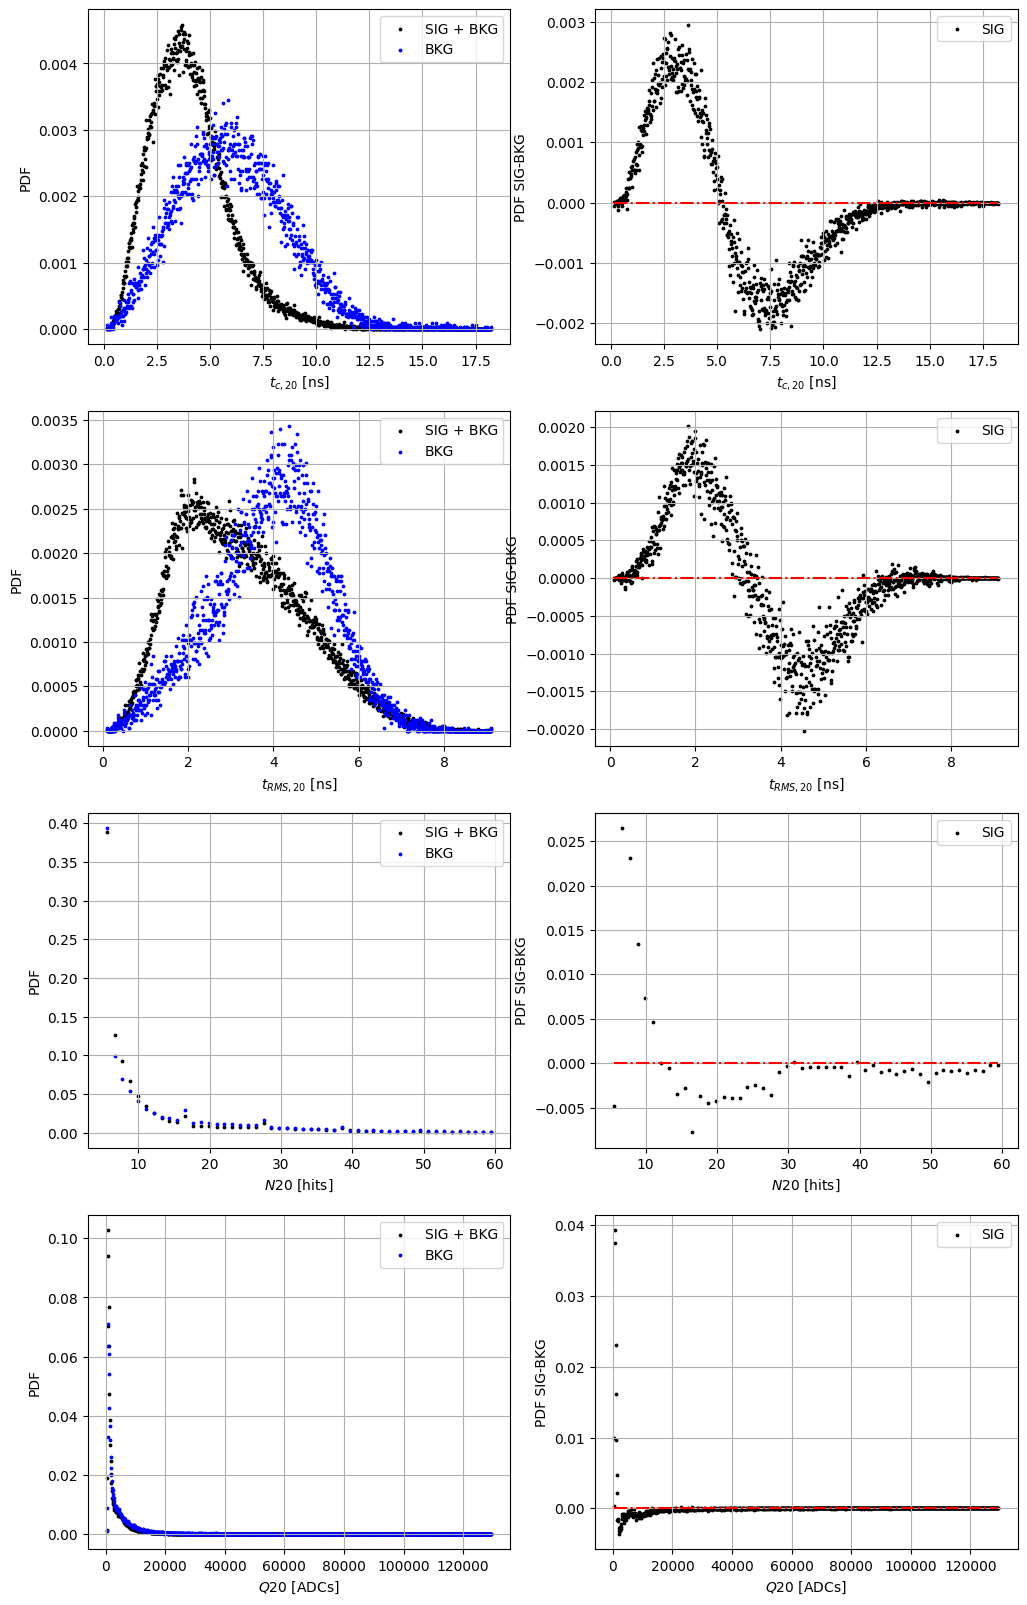

In [24]:
subplot = pltext.canvas(8)
###################################
# tc
###################################
hs = np.histogram(tc_20_sig, 1000);
hb = np.histogram(tc_20_bkg, 1000);

# Calculamos los centros de los bins
bin_centers = (hs[1][:-1] + hs[1][1:]) / 2

subplot(1)
plt.scatter(bin_centers, hs[0]/np.sum(hs[0]), s=3, label="SIG + BKG")
plt.scatter(bin_centers, hb[0]/np.sum(hb[0]), s=3, label="BKG")
plt.xlabel("$t_{c, 20}$ [ns]")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

subplot(2)
sub = (hs[0]/np.sum(hs[0])) - (hb[0]/np.sum(hb[0]))
plt.scatter(bin_centers, sub, s=3, label="SIG")
plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
plt.xlabel("$t_{c, 20}$ [ns]")
plt.grid(True);
plt.ylabel("PDF SIG-BKG");
plt.legend();

###################################
# trms
###################################
hs = np.histogram(trms_20_sig, 1000);
hb = np.histogram(trms_20_bkg, 1000);

# Calculamos los centros de los bins
bin_centers = (hs[1][:-1] + hs[1][1:]) / 2

subplot(3)
plt.scatter(bin_centers, hs[0]/np.sum(hs[0]), s=3, label="SIG + BKG")
plt.scatter(bin_centers, hb[0]/np.sum(hb[0]), s=3, label="BKG")
plt.xlabel("$t_{RMS, 20}$ [ns]")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

subplot(4)
sub = (hs[0]/np.sum(hs[0])) - (hb[0]/np.sum(hb[0]))
plt.scatter(bin_centers, sub, s=3, label="SIG")
plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
plt.xlabel("$t_{RMS, 20}$ [ns]")
plt.grid(True);
plt.ylabel("PDF SIG-BKG");
plt.legend();

###################################
# nhits
###################################
hs = np.histogram(nhits_sig, 50);
hb = np.histogram(nhits_bkg, 50);

# Calculamos los centros de los bins
bin_centers = (hs[1][:-1] + hs[1][1:]) / 2

subplot(5)
plt.scatter(bin_centers, hs[0]/np.sum(hs[0]), s=3, label="SIG + BKG")
plt.scatter(bin_centers, hb[0]/np.sum(hb[0]), s=3, label="BKG")
plt.xlabel("$N20$ [hits]")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

subplot(6)
sub = (hs[0]/np.sum(hs[0])) - (hb[0]/np.sum(hb[0]))
plt.scatter(bin_centers, sub, s=3, label="SIG")
plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
plt.xlabel("$N20$ [hits]")
plt.grid(True);
plt.ylabel("PDF SIG-BKG");
plt.legend();

###################################
# charge
###################################
hs = np.histogram(qsum_20_sig, 1000);
hb = np.histogram(qsum_20_bkg, 1000);

# Calculamos los centros de los bins
bin_centers = (hs[1][:-1] + hs[1][1:]) / 2

subplot(7)
plt.scatter(bin_centers, hs[0]/np.sum(hs[0]), s=3, label="SIG + BKG")
plt.scatter(bin_centers, hb[0]/np.sum(hb[0]), s=3, label="BKG")
plt.xlabel("$Q20$ [ADCs]")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

subplot(8)
sub = (hs[0]/np.sum(hs[0])) - (hb[0]/np.sum(hb[0]))
plt.scatter(bin_centers, sub, s=3, label="SIG")
plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
plt.xlabel("$Q20$ [ADCs]")
plt.grid(True);
plt.ylabel("PDF SIG-BKG");
plt.legend();

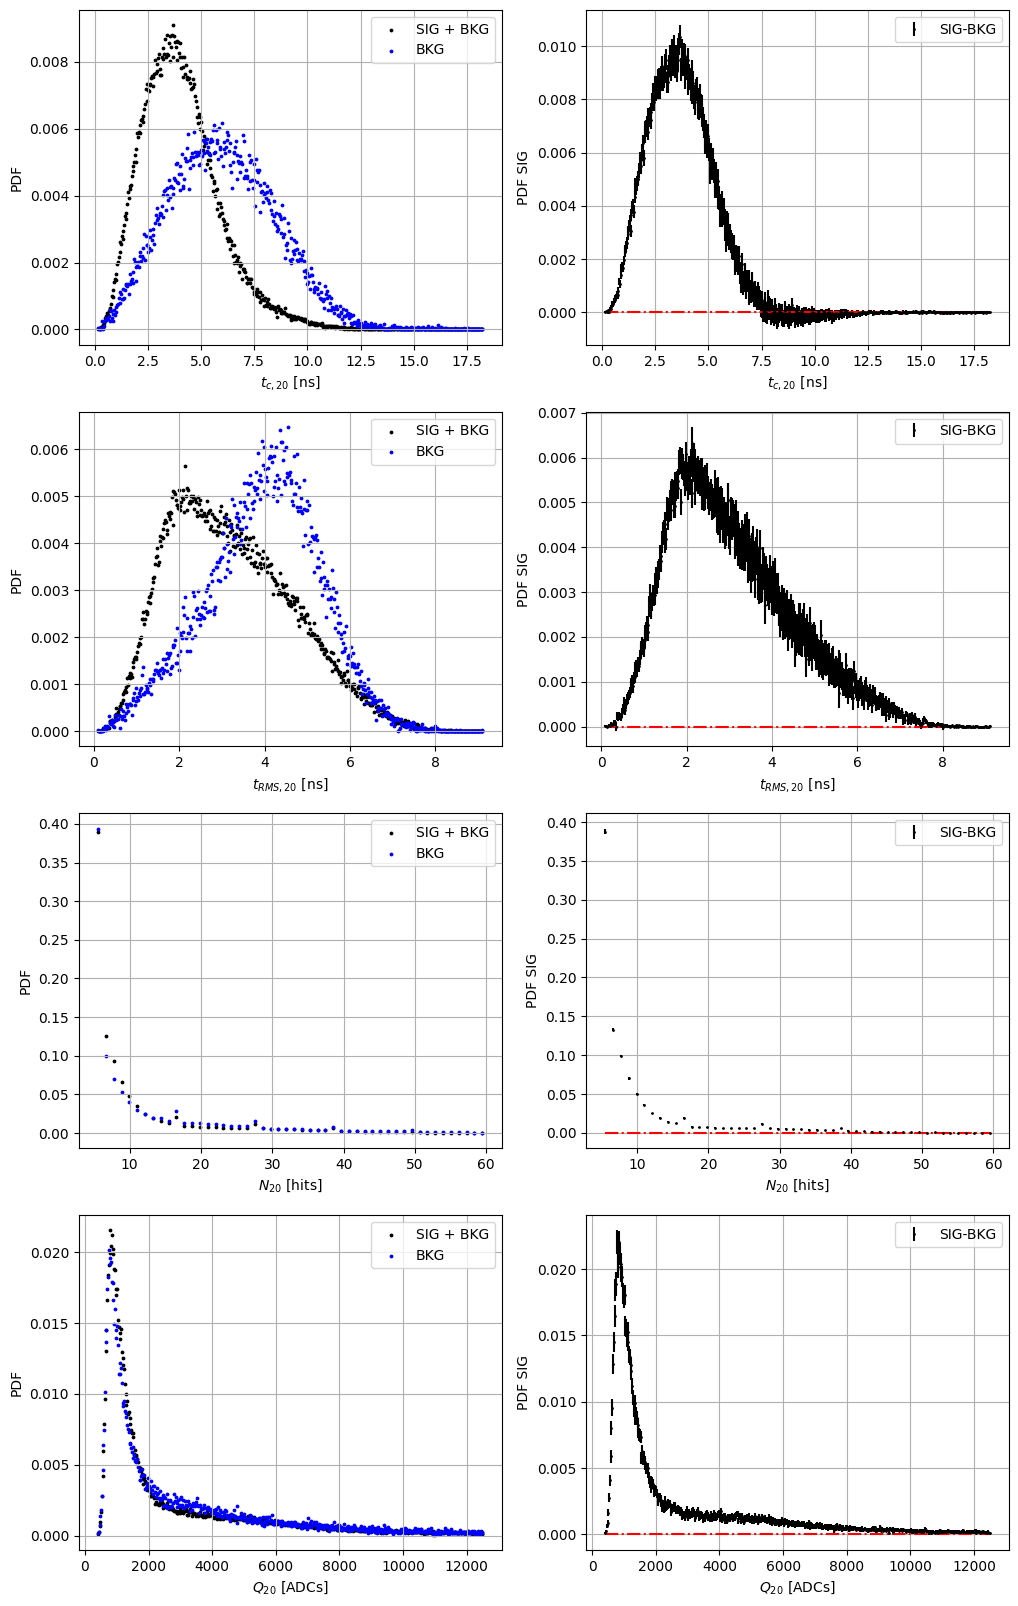

In [25]:
def plot_pdf_with_sub(sig_list, bkg_list, bins, xlabel, subplot_idx, range=None):
    subplot(subplot_idx)  # activa la subventana
    hs = np.histogram(sig_list, bins=bins, range=range)
    hb = np.histogram(bkg_list, bins=bins, range=range)
    
    bin_centers = (hs[1][:-1] + hs[1][1:]) / 2
    pdf_sig = hs[0] / np.sum(hs[0])
    pdf_bkg = hb[0] / np.sum(hb[0])

    # Errores Poisson
    err_sig = np.sqrt(hs[0]) / np.sum(hs[0])
    err_bkg = np.sqrt(hb[0]) / np.sum(hb[0])

    # PDF SIG/BKG
    plt.scatter(bin_centers, pdf_sig, s=3, label="SIG + BKG")
    plt.scatter(bin_centers, pdf_bkg, s=3, label="BKG")
    plt.xlabel(xlabel)
    plt.ylabel("PDF")
    plt.grid(True)
    # plt.yscale("log")
    plt.legend()

    # Diferencia SIG-BKG
    subplot(subplot_idx + 1)
    diff = (pdf_sig - pdf_bkg*0.2)/0.8
    diff_err = np.sqrt((err_sig)**2 + (err_bkg)**2)
    plt.errorbar(bin_centers, diff, yerr=diff_err, fmt='o', markersize=1, label="SIG-BKG")
    plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
    plt.xlabel(xlabel)
    plt.ylabel("PDF SIG")
    plt.grid(True)
    # plt.yscale("log")
    plt.legend()

    return bin_centers, pdf_sig, pdf_bkg

subplot = pltext.canvas(8)  # 3 variables × 2 subplots cada una
bin_centers_tc, pdf_sig_tc, pdf_bkg_tc          = plot_pdf_with_sub(tc_20_sig, tc_20_bkg, 500, "$t_{c, 20}$ [ns]", 1)
bin_centers_trms, pdf_sig_trms, pdf_bkg_trms    = plot_pdf_with_sub(trms_20_sig, trms_20_bkg, 500, "$t_{RMS, 20}$ [ns]", 3)
bin_centers_nhits, pdf_sig_nhits, pdf_bkg_nhits = plot_pdf_with_sub(nhits_sig, nhits_bkg, 50, "$N_{20}$ [hits]", 5)
bin_centers_qsum, pdf_sig_qsum, pdf_bkg_qsum    = plot_pdf_with_sub(qsum_20_sig, qsum_20_bkg, 500, "$Q_{20}$ [ADCs]", 7, range=(400, 12.5e3))

# 2nd Purity Calculation

In [26]:
nicf_triggered_signal_hit_times_tof_clean_shifted = {
    k: [
        arr - nicf_d_seed_tof_clean[k][i]
        for i, arr in enumerate(arrays)
    ]
    for k, arrays in nicf_triggered_signal_hit_times_tof_clean.items()
    if k in nicf_d_seed_tof_clean
}

bkg_triggered_signal_hit_times_tof_clean_shifted = {
    k: [
        arr - bkg_d_seed_tof_clean[k][i]
        for i, arr in enumerate(arrays)
    ]
    for k, arrays in bkg_triggered_signal_hit_times_tof_clean.items()
    if k in bkg_d_seed_tof_clean
}

### New Code Physically Correct

In [27]:
def compute_tc_20(shifted_times):
    mask = (shifted_times >= 0) & (shifted_times <= 20)
    if np.any(mask):
        return np.mean(shifted_times[mask])
    return None

nicf_triggered_signal_hit_times_tof_clean_shifted_tc = {}
nicf_triggered_signal_hits_index_tof_clean_tc = {}

for k, arrays in nicf_triggered_signal_hit_times_tof_clean_shifted.items():
    if k not in nicf_triggered_signal_hits_index_tof_clean:
        continue

    new_times = []
    new_indices = []

    for i, arr in enumerate(arrays):
        tc20 = compute_tc_20(arr)

        if tc20 is not None and tc20 <= 5.0:
            new_times.append(arr)
            new_indices.append(nicf_triggered_signal_hits_index_tof_clean[k][i])

    nicf_triggered_signal_hit_times_tof_clean_shifted_tc[k] = new_times
    nicf_triggered_signal_hits_index_tof_clean_tc[k]        = new_indices

bkg_triggered_signal_hit_times_tof_clean_shifted_tc = {}
bkg_triggered_signal_hits_index_tof_clean_tc = {}

for k, arrays in bkg_triggered_signal_hit_times_tof_clean_shifted.items():
    if k not in bkg_triggered_signal_hits_index_tof_clean:
        continue

    new_times = []
    new_indices = []

    for i, arr in enumerate(arrays):
        tc20 = compute_tc_20(arr)

        if tc20 is not None and tc20 <= 5.0:
            new_times.append(arr)
            new_indices.append(bkg_triggered_signal_hits_index_tof_clean[k][i])

    bkg_triggered_signal_hit_times_tof_clean_shifted_tc[k] = new_times
    bkg_triggered_signal_hits_index_tof_clean_tc[k]        = new_indices

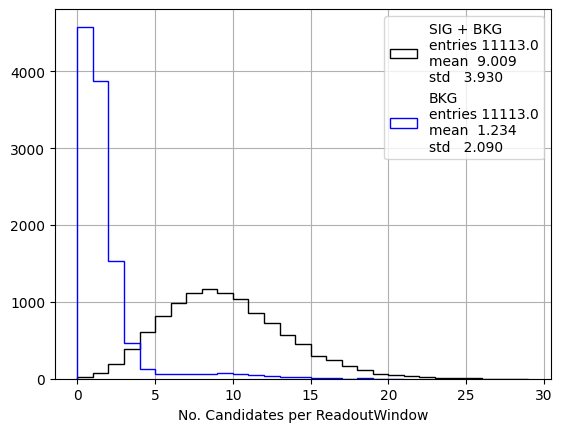

In [28]:
# 2. Cuántos candidatos hay en una readout window?
candidates_per_redaoutWindow_sig_clean_tc = []
for k,v in nicf_triggered_signal_hit_times_tof_clean_shifted_tc.items():
    candidates_per_redaoutWindow_sig_clean_tc.append(len(v))

candidates_per_redaoutWindow_bkg_clean_tc = []
for k,v in bkg_triggered_signal_hit_times_tof_clean_shifted_tc.items():
    candidates_per_redaoutWindow_bkg_clean_tc.append(len(v))

pltext.hist(candidates_per_redaoutWindow_sig_clean_tc, np.max(candidates_per_redaoutWindow_sig_clean_tc), xylabels="No. Candidates per ReadoutWindow", label="SIG + BKG");
pltext.hist(candidates_per_redaoutWindow_bkg_clean_tc, np.max(candidates_per_redaoutWindow_bkg_clean_tc), xylabels="No. Candidates per ReadoutWindow", label="BKG");

In [29]:
(9.009-1.234)/9.009*100

86.3025863025863

# 3rd Purity Calculation

In [30]:
# Filtramos la carga también

nicf_triggered_signal_hit_times_tof_clean_shifted_tc_q20 = {}
nicf_triggered_signal_hits_index_tof_clean_tc_q20        = {}

for k, arrays in nicf_triggered_signal_hit_times_tof_clean_shifted_tc.items():
    if k not in nicf_triggered_signal_hits_index_tof_clean_tc:
        continue

    new_times   = []
    new_indices = []

    for i, arr in enumerate(arrays):
        mask_20        = (arr >= 0) & (arr <= 20)
        hit_indices_20 = nicf_triggered_signal_hits_index_tof_clean_tc[k][i][mask_20]
        charges_20     = ak.to_numpy(nicf_run_tof_hit_charges[k][hit_indices_20])
        q20            = np.sum(charges_20)

        if 400 <= q20 <= 12500:
            new_times.append(arr)
            new_indices.append(nicf_triggered_signal_hits_index_tof_clean_tc[k][i])

    nicf_triggered_signal_hit_times_tof_clean_shifted_tc_q20[k] = new_times
    nicf_triggered_signal_hits_index_tof_clean_tc_q20[k]        = new_indices


bkg_triggered_signal_hit_times_tof_clean_shifted_tc_q20 = {}
bkg_triggered_signal_hits_index_tof_clean_tc_q20        = {}

for k, arrays in bkg_triggered_signal_hit_times_tof_clean_shifted_tc.items():
    if k not in bkg_triggered_signal_hits_index_tof_clean_tc:
        continue

    new_times   = []
    new_indices = []

    for i, arr in enumerate(arrays):
        mask_20        = (arr >= 0) & (arr <= 20)
        hit_indices_20 = bkg_triggered_signal_hits_index_tof_clean_tc[k][i][mask_20]
        charges_20     = ak.to_numpy(bkg_run_hit_charges[k][hit_indices_20])
        q20            = np.sum(charges_20)

        if 400 <= q20 <= 12500:
            new_times.append(arr)
            new_indices.append(bkg_triggered_signal_hits_index_tof_clean_tc[k][i])

    bkg_triggered_signal_hit_times_tof_clean_shifted_tc_q20[k] = new_times
    bkg_triggered_signal_hits_index_tof_clean_tc_q20[k]        = new_indices

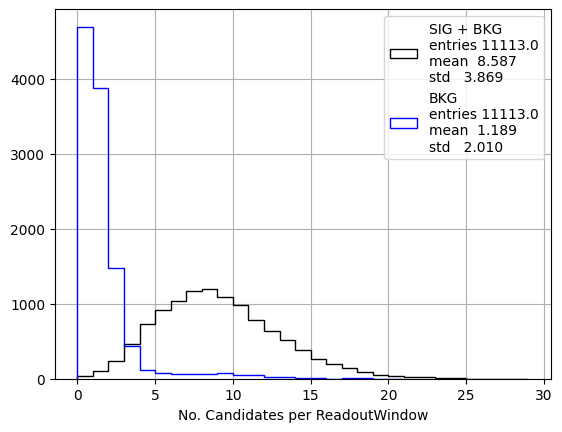

In [31]:
candidates_per_redaoutWindow_sig_clean_tc_q20 = []
for k,v in nicf_triggered_signal_hit_times_tof_clean_shifted_tc_q20.items():
    candidates_per_redaoutWindow_sig_clean_tc_q20.append(len(v))

candidates_per_redaoutWindow_bkg_clean_tc_q20 = []
for k,v in bkg_triggered_signal_hit_times_tof_clean_shifted_tc_q20.items():
    candidates_per_redaoutWindow_bkg_clean_tc_q20.append(len(v))

pltext.hist(candidates_per_redaoutWindow_sig_clean_tc_q20, np.max(candidates_per_redaoutWindow_sig_clean_tc_q20), xylabels="No. Candidates per ReadoutWindow", label="SIG + BKG");
pltext.hist(candidates_per_redaoutWindow_bkg_clean_tc_q20, np.max(candidates_per_redaoutWindow_bkg_clean_tc_q20), xylabels="No. Candidates per ReadoutWindow", label="BKG");

# Save Just 20 ns window Into DFs For BONSAI

In [32]:
# Save DataFrame with only the 20 ns window hits

times_sig     = []
charges_sig   = []
slots_sig     = []
positions_sig = []
candidate_sig = []
events_sig    = []
c = 0
e = 0
for k, v in tqdm(nicf_triggered_signal_hits_index_tof_clean_tc_q20.items(), total=len(nicf_triggered_signal_hits_index_tof_clean_tc_q20)):
    shifted_arrays = nicf_triggered_signal_hit_times_tof_clean_shifted_tc_q20[k]
    for i, hits in enumerate(v):
        shifted_times = shifted_arrays[i]
        mask_20       = (shifted_times >= 0) & (shifted_times <= 20)
        hits_20       = hits[mask_20]

        times_sig    .append(ak.to_numpy(nicf_run_tof_corrected_times    [k][hits_20]))
        charges_sig  .append(ak.to_numpy(nicf_run_tof_hit_charges        [k][hits_20]))
        slots_sig    .append(ak.to_numpy(nicf_run_tof_hit_slot_ids       [k][hits_20]))
        positions_sig.append(ak.to_numpy(nicf_run_tof_hit_position_ids   [k][hits_20]))
        candidate_sig.append(np.zeros(len(hits_20)) + c)
        events_sig   .append(np.zeros(len(hits_20)) + e)
        c += 1
    e += 1

times_bkg     = []
charges_bkg   = []
slots_bkg     = []
positions_bkg = []
candidate_bkg = []
events_bkg    = []
c = 0
e = 0
for k, v in tqdm(bkg_triggered_signal_hits_index_tof_clean_tc_q20.items(), total=len(bkg_triggered_signal_hits_index_tof_clean_tc_q20)):
    shifted_arrays = bkg_triggered_signal_hit_times_tof_clean_shifted_tc_q20[k]
    for i, hits in enumerate(v):
        shifted_times = shifted_arrays[i]
        mask_20       = (shifted_times >= 0) & (shifted_times <= 20)
        hits_20       = hits[mask_20]

        times_bkg    .append(ak.to_numpy(bkg_run_corrected_times         [k][hits_20]))
        charges_bkg  .append(ak.to_numpy(bkg_run_hit_charges             [k][hits_20]))
        slots_bkg    .append(ak.to_numpy(bkg_run_hit_slot_ids            [k][hits_20]))
        positions_bkg.append(ak.to_numpy(bkg_run_hit_position_ids        [k][hits_20]))
        candidate_bkg.append(np.zeros(len(hits_20)) + c)
        events_bkg   .append(np.zeros(len(hits_20)) + e)
        c += 1
    e += 1

times_sig     = np.concatenate(times_sig)
charges_sig   = np.concatenate(charges_sig)
slots_sig     = np.concatenate(slots_sig)
positions_sig = np.concatenate(positions_sig)
candidate_sig = np.concatenate(candidate_sig)
events_sig    = np.concatenate(events_sig)

times_bkg     = np.concatenate(times_bkg)
charges_bkg   = np.concatenate(charges_bkg)
slots_bkg     = np.concatenate(slots_bkg)
positions_bkg = np.concatenate(positions_bkg)
candidate_bkg = np.concatenate(candidate_bkg)
events_bkg    = np.concatenate(events_bkg)

df_sig = pd.DataFrame({
    "event_id":                 events_sig.astype(int),
    "candidate_id":             candidate_sig.astype(int),
    "hit_pmt_calibrated_times": times_sig,
    "hit_pmt_charges":          charges_sig,
    "hit_mpmt_slot_ids":        slots_sig.astype(int),
    "hit_pmt_position_ids":     positions_sig.astype(int),
})

df_bkg = pd.DataFrame({
    "event_id":                 events_bkg.astype(int),
    "candidate_id":             candidate_bkg.astype(int),
    "hit_pmt_calibrated_times": times_bkg,
    "hit_pmt_charges":          charges_bkg,
    "hit_mpmt_slot_ids":        slots_bkg.astype(int),
    "hit_pmt_position_ids":     positions_bkg.astype(int),
})

# df_sig.to_csv("data_files/testWithoutTOF_sig1767_20nsTcQ20_window20ns.csv", index=False)
# df_bkg.to_csv("data_files/testWithoutTOF_bkg1766_20nsTcQ20_window20ns.csv", index=False)

  0%|          | 0/11113 [00:00<?, ?it/s]

 27%|██▋       | 3033/11113 [00:26<01:09, 116.59it/s]


KeyboardInterrupt: 

# Save Data Into DFs

In [ ]:
times_sig     = []
charges_sig   = []
slots_sig     = []
positions_sig = []
candidate_sig = []
events_sig    = []

c = 0
e = 0
for k,v in tqdm(nicf_triggered_signal_hits_index_tof_clean_tc_q20.items(), total=len(nicf_triggered_signal_hits_index_tof_clean_tc_q20)):
    for hits in v:
        times_sig.append(nicf_run_tof_corrected_times[k][hits])
        charges_sig.append(nicf_run_tof_hit_charges[k][hits])
        slots_sig.append(nicf_run_tof_hit_slot_ids[k][hits])
        positions_sig.append(nicf_run_tof_hit_position_ids[k][hits])
        candidate_sig.append(np.zeros(len(hits))+c)
        events_sig.append(np.zeros(len(hits))+e)
        c+=1
    e+=1

times_bkg     = []
charges_bkg   = []
slots_bkg     = []
positions_bkg = []
candidate_bkg = []
events_bkg    = []

c = 0
e = 0
for k,v in tqdm(bkg_triggered_signal_hits_index_tof_clean_tc_q20.items(), total=len(bkg_triggered_signal_hits_index_tof_clean_tc_q20)):
    for hits in v:
        times_bkg.append(bkg_run_corrected_times[k][hits])
        charges_bkg.append(bkg_run_hit_charges[k][hits])
        slots_bkg.append(bkg_run_hit_slot_ids[k][hits])
        positions_bkg.append(bkg_run_hit_position_ids[k][hits])
        candidate_bkg.append(np.zeros(len(hits))+c)
        events_bkg.append(np.zeros(len(hits))+e)
        c+=1
    e+=1

100%|██████████| 11113/11113 [00:11<00:00, 993.20it/s] 


In [ ]:
times_sig     = np.concatenate(times_sig)
charges_sig   = np.concatenate(charges_sig)
slots_sig     = np.concatenate(slots_sig)
positions_sig = np.concatenate(positions_sig)
candidate_sig = np.concatenate(candidate_sig)
events_sig    = np.concatenate(events_sig)

times_bkg     = np.concatenate(times_bkg)
charges_bkg   = np.concatenate(charges_bkg)
slots_bkg     = np.concatenate(slots_bkg)
positions_bkg = np.concatenate(positions_bkg)
candidate_bkg = np.concatenate(candidate_bkg)
events_bkg    = np.concatenate(events_bkg)

In [ ]:
df_sig = pd.DataFrame({
    "event_id":                 events_sig,
    "candidate_id":             candidate_sig,
    "hit_pmt_calibrated_times": times_sig,
    "hit_pmt_charges":          charges_sig,
    "hit_mpmt_slot_ids":        slots_sig,
    "hit_pmt_position_ids":     positions_sig
})

df_bkg = pd.DataFrame({
    "event_id":                 events_bkg,
    "candidate_id":             candidate_bkg,
    "hit_pmt_calibrated_times": times_bkg,
    "hit_pmt_charges":          charges_bkg,
    "hit_mpmt_slot_ids":        slots_bkg,
    "hit_pmt_position_ids":     positions_bkg
})

In [ ]:
# df_sig.to_csv("data_files/testWithoutTOF_sig1767_20nsTcQ20.csv")

# Load Reconstructed Time And Compute Variables

In [33]:
# ─── Carga el output de BONSAI ───────────────────────────────────────────────
df_bonsai = pd.read_csv("/home/usc/ie/dcr/hk/nicf_analysis/bonsai_reco/NB/1767_usingOldCode_DataTcQ2020nsWinCut.csv", index_col=0)

In [34]:
df_bonsai

,candidate,nhits,nhitso,x,y,z,t_vertex_rel,result1,result2,result3,result4,result5,good0,good1,good2,t_vertex_abs
0,13,1182,17,-26.647858,-14.325267,71.534645,2.465119,-0.207402,-0.124472,0.809699,0.261263,17.702236,17.585993,0.956244,0.868108,133052.490721
1,15,1449,25,-13.402538,11.542228,50.535564,2.155943,-0.797965,1.426704,0.636171,0.506332,33.484756,33.235798,0.950735,0.862932,188942.251823
2,55,390,14,-31.736216,62.245361,-3.770264,0.762382,3.061950,-2.849277,0.797472,0.513962,21.929386,21.839952,0.981344,0.926083,430155.007665
3,62,513,16,-56.791538,83.166313,173.330414,2.464206,-1.055807,-1.878389,0.661704,0.495137,11.618656,11.511842,0.963964,0.839762,487683.453407
4,87,459,10,-32.360737,24.404158,-238.848557,0.763662,0.278427,3.020396,0.897697,0.782602,7.722251,7.309524,0.956844,0.896341,191960.964505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8366,95346,785,18,-85.279968,-243.180405,139.369629,1.894343,1.077978,-1.896983,0.943349,0.437623,19.771961,19.133804,0.877144,0.870925,218705.875304
8367,95348,1418,26,42.450550,4.518111,-25.754362,0.620841,-2.734171,0.062112,0.637143,0.141968,42.012821,41.770359,0.968197,0.884837,434046.253597
8368,95390,843,16,-42.745564,-44.610699,103.022003,1.812832,1.692990,1.675936,0.668350,0.883437,6.261421,6.181883,0.873999,0.804313,136005.609147
8369,95407,1472,30,-30.738905,36.466686,50.824654,0.948273,-1.216627,-2.067786,0.513754,0.735594,35.672180,33.918663,0.914187,0.825478,40384.122073


In [36]:
# ─── Sanity Check: df_bonsai vs diccionario del notebook ─────────────────────

print("=" * 55)
print("SANITY CHECK: df_bonsai vs diccionario notebook")
print("=" * 55)

# 1. Número total de candidatos en el diccionario
total_candidates_notebook = sum(
    len(arrays)
    for arrays in nicf_triggered_signal_hit_times_tof_clean_shifted_tc_q20.values()
)
total_candidates_bonsai = len(df_bonsai)

print(f"\n[1] Total candidatos en diccionario notebook : {total_candidates_notebook}")
print(f"    Total candidatos en df_bonsai            : {total_candidates_bonsai}")
print(f"    Candidatos perdidos en BONSAI            : {total_candidates_notebook - total_candidates_bonsai}")
print(f"    Fracción reconstruida                    : {total_candidates_bonsai / total_candidates_notebook * 100:.1f}%")

# 2. candidate_ids en df_bonsai son únicos?
n_unique = df_bonsai["candidate"].nunique()
print(f"\n[2] candidate_ids únicos en df_bonsai        : {n_unique}")
print(f"    Filas totales en df_bonsai               : {total_candidates_bonsai}")
if n_unique != total_candidates_bonsai:
    print(f"    *** AVISO: hay candidate_ids duplicados — BONSAI encontró")
    print(f"        múltiples triggers dentro de algún candidato ***")
    dupes = df_bonsai[df_bonsai.duplicated("candidate_id", keep=False)]
    print(f"    Candidatos afectados: {dupes['candidate'].nunique()}")
    print(dupes[["candidate", "nhits", "nhitso", "x", "y", "z"]].head(10))
else:
    print(f"    OK: todos los candidate_ids son únicos")

# 3. Rango de candidate_ids en df_bonsai vs esperado
expected_ids  = set(range(total_candidates_notebook))
bonsai_ids    = set(df_bonsai["candidate"].values)
missing_ids   = expected_ids - bonsai_ids
unexpected_ids= bonsai_ids - expected_ids

print(f"\n[3] candidate_ids esperados (0 a {total_candidates_notebook-1})")
print(f"    IDs presentes en df_bonsai   : {len(bonsai_ids)}")
print(f"    IDs ausentes (fallos BONSAI) : {len(missing_ids)}")
if unexpected_ids:
    print(f"    *** AVISO: IDs inesperados   : {unexpected_ids} ***")
else:
    print(f"    IDs inesperados              : ninguno  OK")

# 4. Comprueba que nhits de BONSAI es consistente con el tamaño
#    de la ventana de 20 ns en el diccionario
print(f"\n[4] Comprobación nhitso vs nhits en ventana 20 ns...")

candidate_counter = 0
mismatches        = []

for k, arrays in nicf_triggered_signal_hit_times_tof_clean_shifted_tc_q20.items():
    for i, shifted_arr in enumerate(arrays):

        if candidate_counter not in bonsai_ids:
            candidate_counter += 1
            continue

        mask_20   = (shifted_arr >= 0) & (shifted_arr <= 20)
        nhits_nb  = int(np.sum(mask_20))
        nhitso_bs = int(df_bonsai.loc[df_bonsai["candidate"] == candidate_counter, "nhitso"].values[0])

        if nhits_nb != nhitso_bs:
            mismatches.append({
                "candidate_id": candidate_counter,
                "nhits_notebook": nhits_nb,
                "nhitso_bonsai":  nhitso_bs,
                "diff": nhits_nb - nhitso_bs
            })

        candidate_counter += 1

if mismatches:
    print(f"    *** AVISO: {len(mismatches)} candidatos con nhits inconsistente ***")
    print(pd.DataFrame(mismatches).head(10).to_string(index=False))
else:
    print(f"    OK: nhits consistente en todos los candidatos reconstruidos")

print("\n" + "=" * 55)

SANITY CHECK: df_bonsai vs diccionario notebook

[1] Total candidatos en diccionario notebook : 95423
    Total candidatos en df_bonsai            : 8371
    Candidatos perdidos en BONSAI            : 87052
    Fracción reconstruida                    : 8.8%

[2] candidate_ids únicos en df_bonsai        : 8371
    Filas totales en df_bonsai               : 8371
    OK: todos los candidate_ids son únicos

[3] candidate_ids esperados (0 a 95422)
    IDs presentes en df_bonsai   : 8371
    IDs ausentes (fallos BONSAI) : 87052
    IDs inesperados              : ninguno  OK

[4] Comprobación nhitso vs nhits en ventana 20 ns...
    *** AVISO: 8371 candidatos con nhits inconsistente ***
 candidate_id  nhits_notebook  nhitso_bonsai  diff
           13              28             17    11
           15              36             25    11
           55              25             14    11
           62              17             16     1
           87              14             10     4
     

In [39]:
C_WATER = 299.792 / 1.34  # velocidad de la luz en agua [mm/ns]

geo = pd.read_csv(
    "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/"
    "geofile_NuPRISMBeamTest_16cShort_mPMT.txt",
    index_col=False, sep=r'\s+', skiprows=5,
    names=["id","mpmtid","spmtid","x","y","z","dx","dy","dz","cyloc"]
)
geo_lookup = {
    (row.mpmtid, row.spmtid): np.array([row.x, row.y, row.z])
    for row in geo.itertuples(index=False)
}

bonsai_lookup = df_bonsai.set_index("candidate").to_dict(orient="index")

nicf_hit_times_tof_corrected         = {}
nicf_hit_times_tof_corrected_shifted = {}

candidate_counter = 0

for k, arrays in nicf_triggered_signal_hit_times_tof_clean_shifted_tc_q20.items():
    corrected_arrays = []
    shifted_arrays   = []

    for i, shifted_arr in enumerate(arrays):

        if candidate_counter not in bonsai_lookup:
            # Candidato sin reconstrucción BONSAI → lo saltamos
            candidate_counter += 1
            continue

        mask_20  = (shifted_arr >= 0) & (shifted_arr <= 20)
        hits_20  = nicf_triggered_signal_hits_index_tof_clean_tc_q20[k][i][mask_20]

        abs_times = ak.to_numpy(nicf_run_tof_corrected_times [k][hits_20])
        slot_ids  = ak.to_numpy(nicf_run_tof_hit_slot_ids    [k][hits_20])
        pos_ids   = ak.to_numpy(nicf_run_tof_hit_position_ids[k][hits_20])

        row      = bonsai_lookup[candidate_counter]
        t_vertex = row["t_vertex_abs"]
        v_pos    = np.array([row["x"], row["y"], row["z"]])

        pmt_positions = np.array([
            geo_lookup.get((s + 1, p + 1), np.array([np.nan, np.nan, np.nan]))
            for s, p in zip(slot_ids, pos_ids)
        ])
        dists       = np.linalg.norm(pmt_positions - v_pos, axis=1)
        tof         = dists / C_WATER
        t_corrected = abs_times - t_vertex - tof

        corrected_arrays.append(t_corrected)
        shifted_arrays  .append(t_corrected - np.min(t_corrected))

        candidate_counter += 1

    nicf_hit_times_tof_corrected        [k] = corrected_arrays
    nicf_hit_times_tof_corrected_shifted[k] = shifted_arrays

print(f"Candidatos totales en diccionario : {candidate_counter}")
print(f"Candidatos con corrección ToF     : {sum(len(v) for v in nicf_hit_times_tof_corrected.values())}")
print(f"Candidatos saltados (sin BONSAI)  : {candidate_counter - len(bonsai_lookup)}")

Candidatos totales en diccionario : 95423
Candidatos con corrección ToF     : 8371
Candidatos saltados (sin BONSAI)  : 87052


In [51]:
tc = []
trms = []
for k,v in nicf_hit_times_tof_corrected.items():
    for c in v:
        try:
            tc.append(np.nanmean(c))
            trms.append(np.nanstd(c))
        except:
            continue

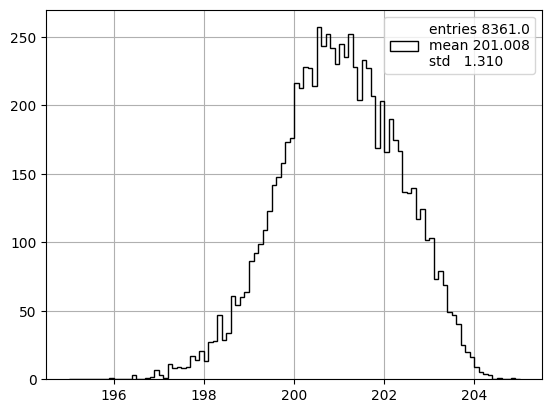

In [60]:
pltext.hist(tc, 100, stats=True, range=(195, 205));

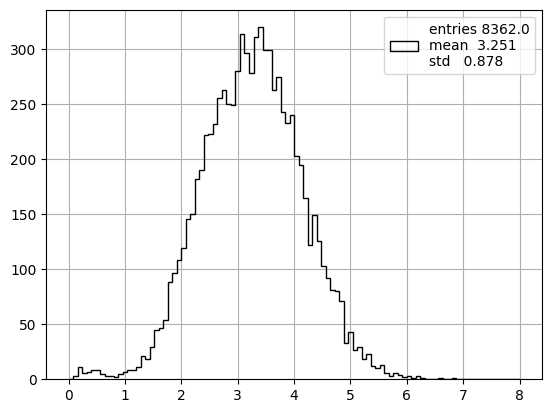

In [63]:
pltext.hist(trms, 100, range=(0, 8));